# Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score


# Load Dataset and shows first 5 rows

In [ ]:
df = pd.read_csv('StudentPerformanceFactors.csv')
print(df.head())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

# Understand Dataset

In [ ]:
df.columns

# Columns → what features exist

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [ ]:
df.info()
# info → data types + nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
df.describe()
# describe → stats

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


describe → stats

# Handle Missing Values

In [ ]:
df = df.dropna()
# ML models don’t accept null values

# Select Features and Target

In [ ]:
X = df[['Hours_Studied','Attendance','Sleep_Hours']]
y = df['Exam_Score']

# X → inputs
# y → output (what we predict)

In [ ]:
df = pd.get_dummies(df, drop_first=True)
# ML needs numeric values / if my dataset have a 'yes/No' in columns

# Train-Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Train → learning
# Test → checking performance

# Train Model

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

# Model learns relationship between inputs and marks

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Predictions

In [ ]:
y_pred = model.predict(X_test)

# Evaluate Model

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print('RMSE:',rmse)
print('R2:',r2)

# RMSE → error (lower = better)
# R² → accuracy (closer to 1 = better)

RMSE: 2.6492717268841144
R2: 0.5483304011758172


# Actual vs Predicted

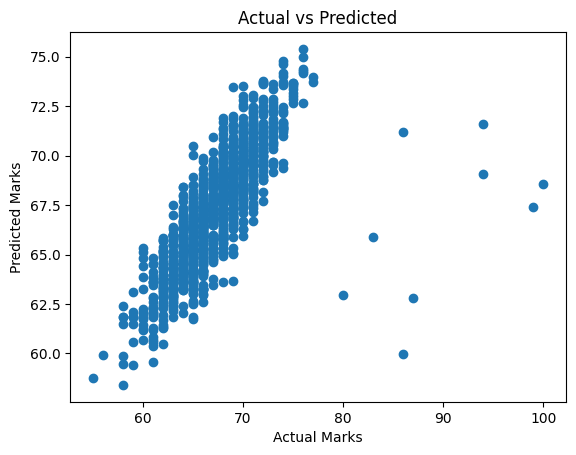

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")
plt.show()

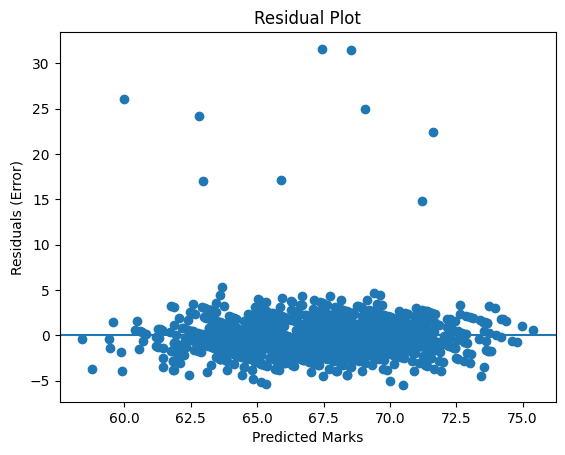

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Marks")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot")
plt.show()

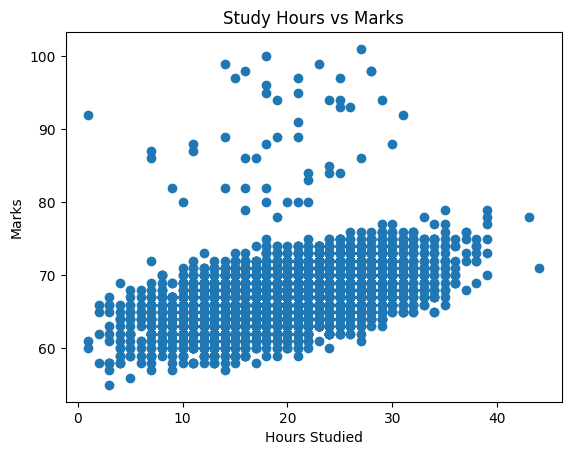

In [ ]:
plt.scatter(df["Hours_Studied"], df["Exam_Score"])
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")
plt.show()

# Compare Result

In [ ]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results.head())

      Actual  Predicted
2814      74  73.560424
4421      66  65.917904
4282      70  69.831152
1246      72  70.599510
4699      67  65.555626


# Test Customm Input

In [ ]:
new_data = pd.DataFrame({
    'Hours_Studied': [6],
    'Attendance': [80],
    'Sleep_Hours': [7]
})

prediction = model.predict(new_data)
print('Predicted Score:', prediction[0])

Predicted Score: 63.14850614818849


# How to explain this in interview

In [ ]:
# Say this clearly:
#“I compared actual vs predicted values”
#“The difference is small, so model is performing well”
#“There is minor error, which is expected in real data”

In [ ]:
# Model is not perfect, but general trend is captured correctly

In [ ]:
import joblib

# Save the trained model
joblib.dump(model, 'student_model.pkl')

# Save the columns/features used
import json
features = ['Hours_Studied', 'Attendance', 'Sleep_Hours']
with open('features.json', 'w') as f:
    json.dump(features, f)

print("Model saved successfully!")

Model saved successfully!
